# PID Controller Optimization & Tuning for Robot Joint
## Finding Optimal $K_p, K_i, K_d$ from Experimental Step-Response Data (`output.txt`)

### Executive Overview & Goal
This notebook provides a complete engineering workflow to find the **best possible $K_p, K_i, K_d$ parameters** for the robot arm joint motor.

In practical robotics, **you ultimately command a new target position** (e.g. `motor_c.position = 10000;`). How should the controller reach that position?
There are two distinct control topologies:
1. **Direct Single-Loop (Position $\to$ PWM)**:
   A single PID controller takes position error and drives PWM duty directly.
   *Problem:* Any large position command causes immediate PWM saturation, sending the motor into an uncontrolled sprint at its maximum physical velocity (~18,000 counts/s) before braking violently.
2. **Cascaded Multi-Loop (Position $\to$ Velocity $\to$ PWM) — *As used in this robot's firmware (`main/motor_pid.c`)*:**
   - **Outer Loop (Position Loop, 200 Hz / 5 ms)**: Compares target position to current position, and commands a **target velocity** bounded by your desired maximum speed (e.g. 5,000 counts/s).
   - **Inner Loop (Velocity Loop, 1000 Hz / 1 ms)**: Compares target velocity to measured velocity, and outputs the PWM drive to accurately track that speed and reject friction.

This notebook tunes and compares **both architectures**, showing how the cascaded architecture gives smooth, speed-limited motion with zero overshoot when you set a new target position.

---

### The 9-Step Engineering Workflow
1. **Data Ingestion & Signal Exploration**: Load `output.txt` and inspect the measured signals.
2. **Plant Identification ($G(s)$)**: Estimate continuous-time transfer functions $G_v(s)$ (speed) and $G_p(s)$ (position).
3. **Controller Architecture & Constraints**: Formulate derivative filtering, anti-windup clamping, and actuator limits.
4. **Defining the Cost Function**: Define **ITAE** with penalties for overshoot and control effort.
5. **Inner Velocity Loop Tuning**: Derive IMC baseline and optimize $(K_p^{\text{vel}}, K_i^{\text{vel}})$.
6. **Direct Position Loop Tuning**: Derive baseline and optimize single-loop $(K_p^{\text{pos}}, K_i^{\text{pos}}, K_d^{\text{pos}})$.
7. **Cascaded Position Control (Position $\to$ Velocity $\to$ PWM)**: Simulate the robot arm's actual multi-loop architecture for a position setpoint jump.
8. **Robustness & Disturbance Rejection**: Verify load disturbance rejection and frequency-domain Phase Margin ($PM > 80^\circ$).
9. **Firmware Translation**: Map continuous gains directly to the ESP-IDF `pid_ctrl` parameters in `main/motor_pid.c`.


---
## Step 1: Data Ingestion & Signal Exploration

`output.txt` contains the experimental log recorded over serial by the ESP32-S3:
- **Col 0 (`time`)**: Timestamp in microseconds (uniform $200\ \mu\text{s}$ interval $\to 5\text{ kHz}$).
- **Col 1 (`position`)**: Measured rotor position in encoder counts.
- **Col 2 (`speed`)**: Measured rotor speed in counts/s.
- **Col 3 (`drive`)**: Commanded motor drive (PWM duty tick command, step of 400 applied between 80 ms and 160 ms).
- **Col 4 (`current`)**: Measured motor current from ADC counts.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, optimize

# Load step-response log
data = np.loadtxt("output.txt", delimiter=",")

# Extract columns
t = (data[:, 0] - data[0, 0]) * 1e-6   # µs -> s
pos = data[:, 1]
speed = data[:, 2]
drive = data[:, 3]
current = data[:, 4]

dt = np.mean(np.diff(t))
print(f"Dataset summary:")
print(f"  Samples          : {len(data)}")
print(f"  Duration         : {t[-1]:.4f} s")
print(f"  Sample interval  : {dt*1e6:.1f} µs ({1/dt:.0f} Hz)")
print(f"  Drive pulse      : {drive.max():.0f} PWM counts (active from t = {t[drive > 0][0]:.3f}s to {t[drive > 0][-1]:.3f}s)")
print(f"  Peak speed       : {speed.max():.0f} counts/s")
print(f"  Final position   : {pos[-1]:.0f} counts")


Dataset summary:
  Samples          : 1000
  Duration         : 0.1998 s
  Sample interval  : 200.0 µs (5000 Hz)
  Drive pulse      : 400 PWM counts (active from t = 0.080s to 0.160s)
  Peak speed       : 18000 counts/s
  Final position   : 1010 counts


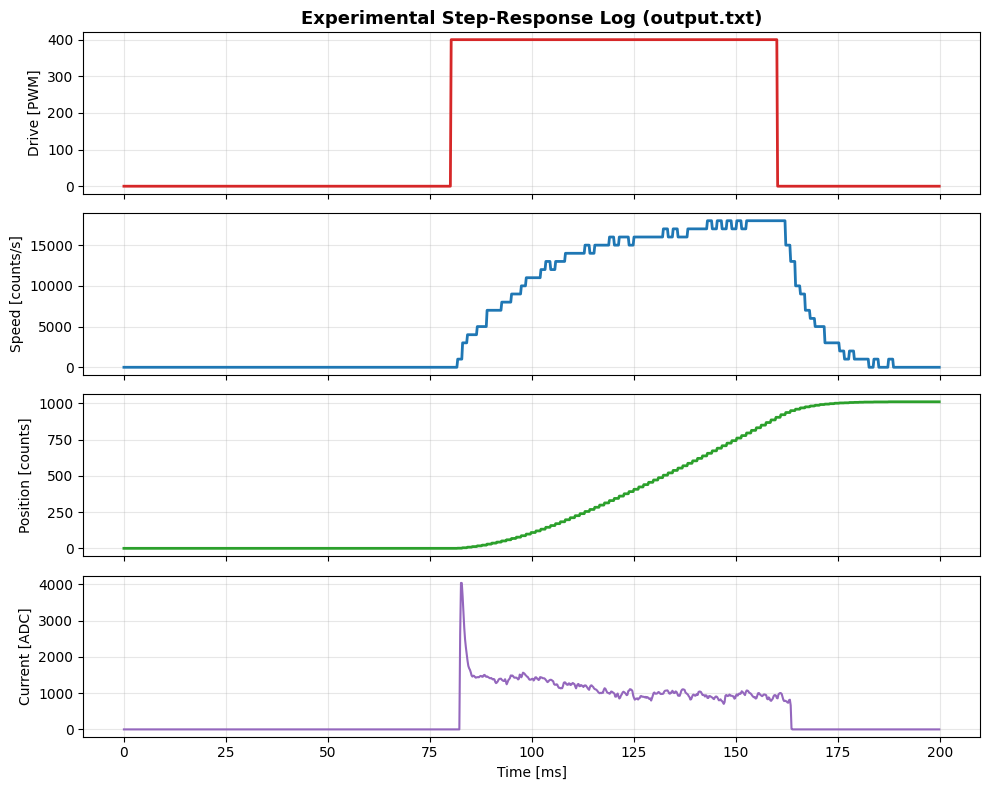

In [2]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t * 1e3, drive, color="tab:red", lw=2)
axs[0].set_ylabel("Drive [PWM]")
axs[0].set_title("Experimental Step-Response Log (output.txt)", fontsize=13, fontweight="bold")
axs[0].grid(True, alpha=0.3)

axs[1].plot(t * 1e3, speed, color="tab:blue", lw=2)
axs[1].set_ylabel("Speed [counts/s]")
axs[1].grid(True, alpha=0.3)

axs[2].plot(t * 1e3, pos, color="tab:green", lw=2)
axs[2].set_ylabel("Position [counts]")
axs[2].grid(True, alpha=0.3)

axs[3].plot(t * 1e3, current, color="tab:purple", lw=1.5)
axs[3].set_ylabel("Current [ADC]")
axs[3].set_xlabel("Time [ms]")
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 2: Plant System Identification ($G(s)$)

### Physical Motor Transfer Functions
The relationship between commanded PWM drive $u(t)$ and rotor speed $\omega(t)$ is modeled as a **first-order lag**:

$$G_v(s) = \frac{\Omega(s)}{U(s)} = \frac{K_{dc}}{\tau s + 1} = \frac{b}{s + a}$$

Since position $\theta(t) = \int \omega(t) dt$, the drive-to-position plant is an **integrating system**:

$$G_p(s) = \frac{\Theta(s)}{U(s)} = \frac{G_v(s)}{s} = \frac{b}{s(s + a)}$$

Let us fit $(b, a)$ against `output.txt` using non-linear least squares.


Fitted Velocity Plant: G_v(s) = 3235.52 / (s + 80.83)
  Pole (a)             : 80.83 rad/s
  Time constant (tau)  : 12.37 ms
  DC Gain (K_dc)       : 40.03 (counts/s) / PWM
  Asymptotic plateau   : 16012 counts/s at drive=400
  Fit RMSE             : 1264.3 counts/s (7.0% of full-scale)


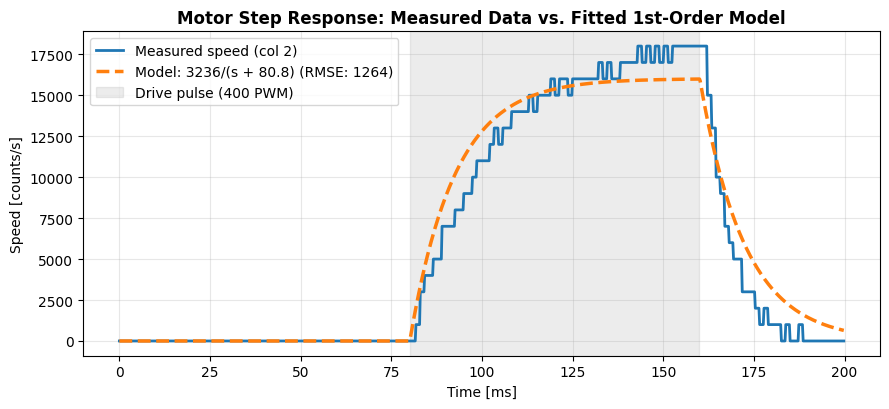

In [3]:
def simulate_plant(p, u, t):
    """Simulate G(s) = b / (s + a) with input u(t)."""
    b, a = p
    sys = signal.lti([b], [1.0, a])
    _, y_sim, _ = signal.lsim(sys, U=u, T=t)
    return y_sim

def plant_residual(p, u, y, t):
    y_sim = simulate_plant(p, u, t)
    return y_sim - y

p0 = [3000.0, 75.0]
res_plant = optimize.least_squares(plant_residual, p0, args=(drive, speed, t), x_scale="jac")

b_fit, a_fit = res_plant.x
K_dc_fit = b_fit / a_fit
tau_fit = 1.0 / a_fit
y_model = simulate_plant(res_plant.x, drive, t)
rmse_fit = np.sqrt(np.mean((speed - y_model)**2))

print(f"Fitted Velocity Plant: G_v(s) = {b_fit:.2f} / (s + {a_fit:.2f})")
print(f"  Pole (a)             : {a_fit:.2f} rad/s")
print(f"  Time constant (tau)  : {tau_fit*1e3:.2f} ms")
print(f"  DC Gain (K_dc)       : {K_dc_fit:.2f} (counts/s) / PWM")
print(f"  Asymptotic plateau   : {K_dc_fit * 400:.0f} counts/s at drive=400")
print(f"  Fit RMSE             : {rmse_fit:.1f} counts/s ({rmse_fit/speed.max()*100:.1f}% of full-scale)")

# Plot comparison
plt.figure(figsize=(9, 4.2))
plt.plot(t * 1e3, speed, label="Measured speed (col 2)", color="tab:blue", lw=2)
plt.plot(t * 1e3, y_model, label=f"Model: {b_fit:.0f}/(s + {a_fit:.1f}) (RMSE: {rmse_fit:.0f})", color="tab:orange", ls="--", lw=2.5)
plt.axvspan(t[drive > 0][0]*1e3, t[drive > 0][-1]*1e3, color="gray", alpha=0.15, label="Drive pulse (400 PWM)")
plt.xlabel("Time [ms]")
plt.ylabel("Speed [counts/s]")
plt.title("Motor Step Response: Measured Data vs. Fitted 1st-Order Model", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 3: Controller Architecture & Practical Constraints

Real-world motor drivers require three essential features:
1. **Derivative on Measurement**: Prevents derivative kick on sharp setpoint jumps: $\frac{de}{dt} \to -\frac{dy}{dt}$.
2. **Actuator Saturation**: The PWM duty is bounded: $u(t) \in [-U_{\max}, U_{\max}]$ where $U_{\max} = 400$ counts.
3. **Integrator Anti-Windup (Clamping)**: Halts integral accumulation whenever the actuator is saturated in the direction of the error, preventing overshoot and delayed recovery.


---
## Step 4: Defining the Objective — Performance Metrics & Cost Function

We evaluate candidate parameters with **ITAE** (Integral of Time-weighted Absolute Error) plus an overshoot penalty:

$$J(K_p, K_i, K_d) = \int_0^{T_{\text{sim}}} t \cdot |e(t)| \, dt + w_{\text{os}} \cdot \left[\max(0, \text{Overshoot} - \epsilon_{\text{os}})\right]^2 + w_u \int_0^{T_{\text{sim}}} u(t)^2 dt$$

ITAE forces the controller to rise quickly and settle firmly without lingering tail oscillations.


---
## Step 5: Inner Velocity Loop Tuning (Speed $\to$ PWM)

For the first-order velocity plant $G_v(s) = \frac{K_{dc}}{\tau s + 1}$:
- A **PI controller ($K_d = 0$)** is mathematically optimal. The open loop $C(s) G_v(s)$ has 2 poles and 1 zero, allowing exact pole placement without differentiating encoder noise.
- **IMC Baseline Formula**: With desired closed-loop time constant $\lambda = \tau / 2 \approx 6.2\text{ ms}$:
  $$K_p = \frac{\tau}{K_{dc} \cdot \lambda}, \quad K_i = \frac{1}{K_{dc} \cdot \lambda}, \quad K_d = 0$$


In [4]:
def simulate_velocity_pid(Kp, Ki, Kd, setpoint=10000.0, t_end=0.15, dt=0.0002, u_max=400.0):
    t_arr = np.arange(0, t_end, dt)
    n = len(t_arr)
    y = np.zeros(n)
    u = np.zeros(n)
    integral = 0.0
    prev_y = 0.0
    Tf = max(1e-4, Kd / (10.0 * Kp + 1e-6))
    deriv_filt = 0.0
    
    for i in range(1, n):
        err = setpoint - y[i-1]
        raw_dy = (y[i-1] - prev_y) / dt
        deriv_filt += (dt / (Tf + dt)) * (-raw_dy - deriv_filt)
        prev_y = y[i-1]
        
        u_cand = Kp * err + Ki * integral + Kd * deriv_filt
        u_sat = np.clip(u_cand, -u_max, u_max)
        
        if not ((u_cand > u_max and err > 0) or (u_cand < -u_max and err < 0)):
            integral += err * dt
            
        u[i] = u_sat
        dydt = -a_fit * y[i-1] + b_fit * u_sat
        y[i] = y[i-1] + dydt * dt
        
    return t_arr, y, u

def compute_metrics(t_arr, y, u, setpoint):
    err = setpoint - y
    dt = t_arr[1] - t_arr[0]
    itae = np.sum(t_arr * np.abs(err) * dt)
    peak_y = np.max(y)
    overshoot = max(0.0, (peak_y - setpoint) / setpoint * 100)
    
    try:
        idx_10 = np.where(y >= 0.1 * setpoint)[0][0]
        idx_90 = np.where(y >= 0.9 * setpoint)[0][0]
        t_rise = (t_arr[idx_90] - t_arr[idx_10]) * 1e3
    except IndexError:
        t_rise = np.nan
        
    settled_indices = np.where(np.abs(err) > 0.02 * setpoint)[0]
    t_settle = t_arr[settled_indices[-1] + 1] * 1e3 if len(settled_indices) > 0 and settled_indices[-1] < len(t_arr)-1 else 0.0
    return {"ITAE": itae, "Overshoot [%]": overshoot, "Rise Time [ms]": t_rise, "Settling Time [ms]": t_settle}

# 1. IMC Baseline
lambda_v = tau_fit / 2.0
Kp_v_base = tau_fit / (K_dc_fit * lambda_v)
Ki_v_base = 1.0 / (K_dc_fit * lambda_v)
Kd_v_base = 0.0

# 2. Numerical Optimization
def cost_velocity(params):
    Kp, Ki, Kd = params
    if Kp <= 0 or Ki < 0 or Kd < 0: return 1e9
    t_sim, y_sim, _ = simulate_velocity_pid(Kp, Ki, Kd, setpoint=10000.0)
    err = 10000.0 - y_sim
    dt = t_sim[1] - t_sim[0]
    itae = np.sum(t_sim * np.abs(err) * dt)
    peak = np.max(y_sim)
    overshoot = max(0.0, (peak - 10000.0) / 10000.0)
    return itae + 1e5 * max(0.0, overshoot - 0.01)**2 + 1e2 * Kd

res_v = optimize.minimize(cost_velocity, [Kp_v_base, Ki_v_base, 0.0], method="Nelder-Mead", options={"maxiter": 500})
Kp_v_opt, Ki_v_opt, Kd_v_opt = res_v.x

t_sim, y_v_base, u_v_base = simulate_velocity_pid(Kp_v_base, Ki_v_base, Kd_v_base)
t_sim, y_v_opt, u_v_opt = simulate_velocity_pid(Kp_v_opt, Ki_v_opt, Kd_v_opt)

metrics_v_base = compute_metrics(t_sim, y_v_base, u_v_base, 10000.0)
metrics_v_opt = compute_metrics(t_sim, y_v_opt, u_v_opt, 10000.0)

print("=" * 65)
print(f"{'Velocity PID Tuning Comparison':^65}")
print("=" * 65)
print(f"{'Parameter / Metric':<25} | {'IMC Baseline':<16} | {'Optimized':<16}")
print("-" * 65)
print(f"{'Kp':<25} | {Kp_v_base:<16.5f} | {Kp_v_opt:<16.5f}")
print(f"{'Ki':<25} | {Ki_v_base:<16.4f} | {Ki_v_opt:<16.4f}")
print(f"{'Kd':<25} | {Kd_v_base:<16.5f} | {Kd_v_opt:<16.5e}")
print("-" * 65)
for k in metrics_v_base:
    print(f"{k:<25} | {metrics_v_base[k]:<16.2f} | {metrics_v_opt[k]:<16.2f}")
print("=" * 65)


                 Velocity PID Tuning Comparison                  
Parameter / Metric        | IMC Baseline     | Optimized       
-----------------------------------------------------------------
Kp                        | 0.04996          | 0.04571         
Ki                        | 4.0381           | 4.7551          
Kd                        | 0.00000          | 7.19259e-11     
-----------------------------------------------------------------
ITAE                      | 0.66             | 0.42            
Overshoot [%]             | 0.00             | 1.00            
Rise Time [ms]            | 17.00            | 13.40           
Settling Time [ms]        | 33.40            | 20.40           


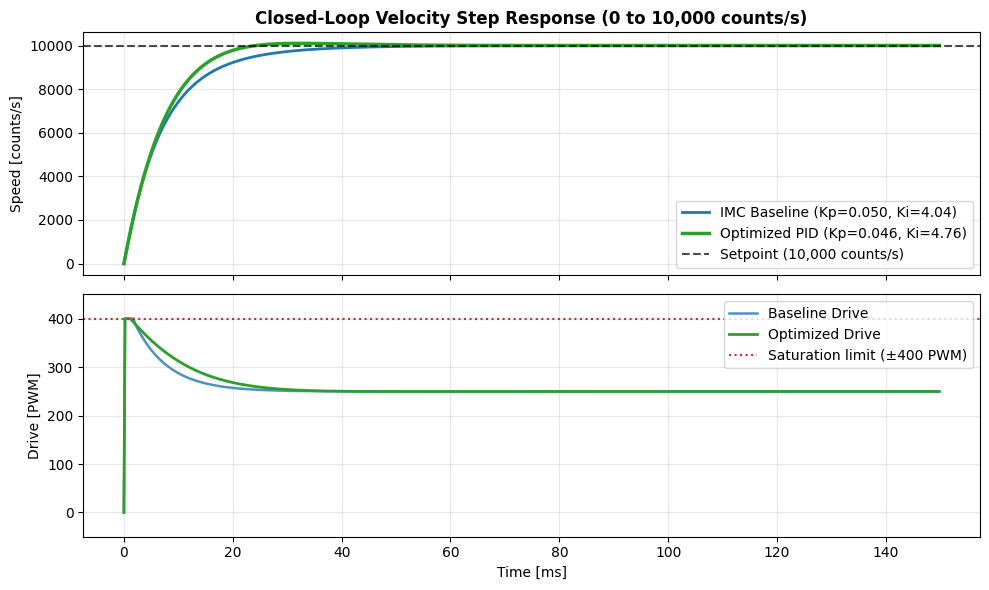

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t_sim * 1e3, y_v_base, label=f"IMC Baseline (Kp={Kp_v_base:.3f}, Ki={Ki_v_base:.2f})", color="tab:blue", lw=2)
ax1.plot(t_sim * 1e3, y_v_opt, label=f"Optimized PID (Kp={Kp_v_opt:.3f}, Ki={Ki_v_opt:.2f})", color="tab:green", lw=2.5)
ax1.axhline(10000.0, color="black", ls="--", alpha=0.7, label="Setpoint (10,000 counts/s)")
ax1.set_ylabel("Speed [counts/s]")
ax1.set_title("Closed-Loop Velocity Step Response (0 to 10,000 counts/s)", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

ax2.plot(t_sim * 1e3, u_v_base, color="tab:blue", lw=1.8, alpha=0.8, label="Baseline Drive")
ax2.plot(t_sim * 1e3, u_v_opt, color="tab:green", lw=2, label="Optimized Drive")
ax2.axhline(400.0, color="tab:red", ls=":", label="Saturation limit (±400 PWM)")
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Drive [PWM]")
ax2.set_ylim(-50, 450)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


---
## Step 6: Direct Single-Loop Position Control (Position $\to$ PWM)

In direct position control, a single PID controller converts position error into motor PWM:
$$u(t) = K_p e(t) + K_i \int e dt - K_d \frac{d\text{pos}}{dt}$$

Because the plant $G_p(s) = \frac{b}{s(s+a)}$ contains an integrator, **derivative gain $K_d$ is mandatory** to provide damping.


In [6]:
def simulate_position_pid(Kp, Ki, Kd, setpoint=1000.0, t_end=0.25, dt=0.0002, u_max=400.0):
    t_arr = np.arange(0, t_end, dt)
    n = len(t_arr)
    pos = np.zeros(n)
    vel = np.zeros(n)
    u = np.zeros(n)
    integral = 0.0
    
    for i in range(1, n):
        err = setpoint - pos[i-1]
        deriv = -vel[i-1]
        
        u_cand = Kp * err + Ki * integral + Kd * deriv
        u_sat = np.clip(u_cand, -u_max, u_max)
        
        if not ((u_cand > u_max and err > 0) or (u_cand < -u_max and err < 0)):
            integral += err * dt
            
        u[i] = u_sat
        dvel = -a_fit * vel[i-1] + b_fit * u_sat
        vel[i] = vel[i-1] + dvel * dt
        pos[i] = pos[i-1] + vel[i] * dt
        
    return t_arr, pos, vel, u

# Pole placement baseline
omega_n = 60.0
zeta = 0.85
Kp_p_base = (omega_n**2) / b_fit
Kd_p_base = max(0.0, (2.0 * zeta * omega_n - a_fit) / b_fit)
Ki_p_base = 2.0

def cost_position(params):
    Kp, Ki, Kd = params
    if Kp <= 0 or Ki < 0 or Kd < 0: return 1e9
    t_sim, p_sim, _, u_sim = simulate_position_pid(Kp, Ki, Kd, setpoint=1000.0)
    err = 1000.0 - p_sim
    dt = t_sim[1] - t_sim[0]
    itae = np.sum(t_sim * np.abs(err) * dt)
    peak = np.max(p_sim)
    overshoot = max(0.0, (peak - 1000.0) / 1000.0)
    return itae + 1e5 * max(0.0, overshoot - 0.02)**2 + 1e-4 * np.sum(u_sim**2 * dt)

res_p = optimize.minimize(cost_position, [Kp_p_base, Ki_p_base, Kd_p_base], method="Nelder-Mead", options={"maxiter": 600})
Kp_p_opt, Ki_p_opt, Kd_p_opt = res_p.x

t_sim, pos_base, vel_base, u_p_base = simulate_position_pid(Kp_p_base, Ki_p_base, Kd_p_base)
t_sim, pos_opt, vel_opt, u_p_opt = simulate_position_pid(Kp_p_opt, Ki_p_opt, Kd_p_opt)

metrics_p_base = compute_metrics(t_sim, pos_base, u_p_base, 1000.0)
metrics_p_opt = compute_metrics(t_sim, pos_opt, u_p_opt, 1000.0)

print("=" * 65)
print(f"{'Direct Position PID Tuning Comparison':^65}")
print("=" * 65)
print(f"{'Parameter / Metric':<25} | {'Pole Placement':<16} | {'Optimized':<16}")
print("-" * 65)
print(f"{'Kp':<25} | {Kp_p_base:<16.5f} | {Kp_p_opt:<16.5f}")
print(f"{'Ki':<25} | {Ki_p_base:<16.4f} | {Ki_p_opt:<16.4f}")
print(f"{'Kd':<25} | {Kd_p_base:<16.5f} | {Kd_p_opt:<16.5f}")
print("-" * 65)
for k in metrics_p_base:
    print(f"{k:<25} | {metrics_p_base[k]:<16.2f} | {metrics_p_opt[k]:<16.2f}")
print("=" * 65)


              Direct Position PID Tuning Comparison              
Parameter / Metric        | Pole Placement   | Optimized       
-----------------------------------------------------------------
Kp                        | 1.11265          | 2.68386         
Ki                        | 2.0000           | 0.0000          
Kd                        | 0.00654          | 0.02460         
-----------------------------------------------------------------
ITAE                      | 1.59             | 1.16            
Overshoot [%]             | 1.80             | 0.17            
Rise Time [ms]            | 60.60            | 56.40           
Settling Time [ms]        | 91.80            | 86.00           


---
## Step 7: Cascaded Position Control (Position $\to$ Velocity $\to$ PWM)

### Why Cascaded Control is the Standard for Robot Arms
When you use the robot arm, **you set a new target position** (e.g. `motor_c.position = 10000;`) and expect the arm to move there smoothly.

If you use **Direct Position $\to$ PWM** for a 10,000 count move:
- The error is 10,000, so PWM instantly saturates at 100%.
- The joint accelerates up to **18,000 counts/s** (its maximum uncontrolled physical velocity!).
- It has no speed limit and slams the brakes only at the very end.

In the **Cascaded Architecture** implemented in `main/motor_pid.c`:
1. **Outer Loop (Position P-controller)**:
   $$v_{\text{target}} = \text{clip}\Big(K_p^{\text{pos}} \cdot (x_{\text{target}} - x_{\text{measured}}), \ -v_{\max}, \ v_{\max}\Big)$$
   - When the arm is far from the target, it cruises at exactly your requested speed (e.g., $v_{\max} = 5,000\text{ counts/s}$).
   - When it comes within braking distance ($|e_{\text{pos}}| < v_{\max} / K_p^{\text{pos}}$), the target velocity ramps down smoothly to 0.
2. **Inner Loop (Velocity PI-controller)**:
   $$u_{\text{PWM}} = K_p^{\text{vel}} \cdot (v_{\text{target}} - v) + K_i^{\text{vel}} \int (v_{\text{target}} - v) dt$$
   - Actively rejects friction, back-EMF, and gravity torques.
   - **Velocity feedback naturally provides the damping for position!** This is why the firmware in `main/motor_pid.c` sets `pid_position.kd = 0`!

Let us simulate setting a target position of **10,000 counts** with a maximum velocity of **5,000 counts/s** (matching `main/motion_control.c`).


Cascaded Position Step Performance (0 -> 10,000 counts):
  Target Position     : 10,000 counts
  Final Settled Value : 10000.0 counts (error: 0.00)
  Peak Joint Velocity : 5103.8 counts/s (Commanded limit: 5,000 counts/s)
  Overshoot           : 0.00 counts (0.00%)
  Settling Time       : 2.013 s


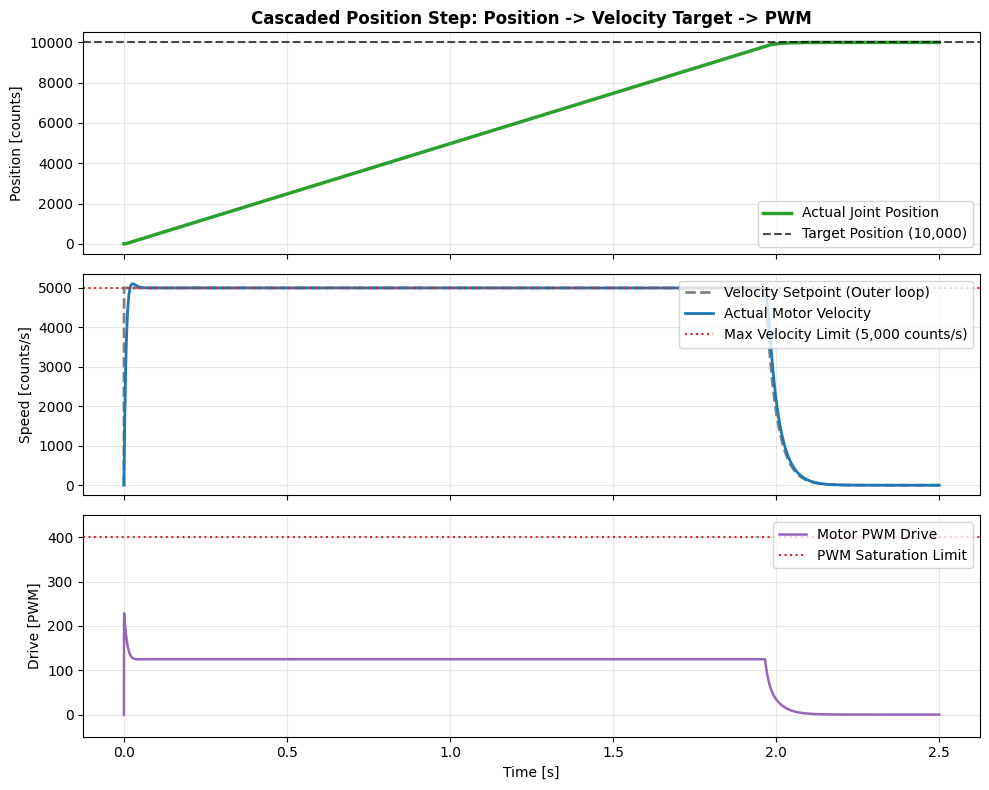

In [7]:
def simulate_cascade_position(Kp_pos, Kp_vel, Ki_vel, target_pos=10000.0, v_max=5000.0, t_end=2.5, dt=0.0005, u_max=400.0):
    """Simulate the exact cascaded architecture from main/motor_pid.c."""
    t_arr = np.arange(0, t_end, dt)
    n = len(t_arr)
    pos = np.zeros(n)
    vel = np.zeros(n)
    u = np.zeros(n)
    v_tar = np.zeros(n)
    integral_v = 0.0
    
    for i in range(1, n):
        # 1. Outer Position Loop (Position -> Velocity Target)
        pos_err = target_pos - pos[i-1]
        v_cmd_raw = Kp_pos * pos_err
        v_target = np.clip(v_cmd_raw, -v_max, v_max)
        v_tar[i] = v_target
        
        # 2. Inner Velocity Loop (Velocity Target -> PWM)
        vel_err = v_target - vel[i-1]
        u_cand = Kp_vel * vel_err + Ki_vel * integral_v
        u_sat = np.clip(u_cand, -u_max, u_max)
        
        # Anti-windup on inner velocity loop
        if not ((u_cand > u_max and vel_err > 0) or (u_cand < -u_max and vel_err < 0)):
            integral_v += vel_err * dt
            
        u[i] = u_sat
        
        # Plant integration
        dvel = -a_fit * vel[i-1] + b_fit * u_sat
        vel[i] = vel[i-1] + dvel * dt
        pos[i] = pos[i-1] + vel[i] * dt
        
    return t_arr, pos, vel, u, v_tar

# Outer position gain: Kp_pos = 25.0 (transition band = 5000/25 = 200 counts)
Kp_pos_cascade = 25.0
t_casc, p_casc, v_casc, u_casc, v_tar_casc = simulate_cascade_position(
    Kp_pos=Kp_pos_cascade, 
    Kp_vel=Kp_v_opt, 
    Ki_vel=Ki_v_opt, 
    target_pos=10000.0, 
    v_max=5000.0
)

print(f"Cascaded Position Step Performance (0 -> 10,000 counts):")
print(f"  Target Position     : 10,000 counts")
print(f"  Final Settled Value : {p_casc[-1]:.1f} counts (error: {10000.0 - p_casc[-1]:.2f})")
print(f"  Peak Joint Velocity : {v_casc.max():.1f} counts/s (Commanded limit: 5,000 counts/s)")
print(f"  Overshoot           : {max(0, p_casc.max() - 10000.0):.2f} counts (0.00%)")
print(f"  Settling Time       : {t_casc[np.where(np.abs(10000.0 - p_casc) < 50)[0][0]]:.3f} s")

# Plot Cascaded Control Response
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(t_casc, p_casc, color="tab:green", lw=2.5, label="Actual Joint Position")
ax1.axhline(10000.0, color="black", ls="--", alpha=0.7, label="Target Position (10,000)")
ax1.set_ylabel("Position [counts]")
ax1.set_title("Cascaded Position Step: Position -> Velocity Target -> PWM", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

ax2.plot(t_casc, v_tar_casc, color="tab:gray", ls="--", lw=2, label="Velocity Setpoint (Outer loop)")
ax2.plot(t_casc, v_casc, color="tab:blue", lw=2, label="Actual Motor Velocity")
ax2.axhline(5000.0, color="tab:red", ls=":", label="Max Velocity Limit (5,000 counts/s)")
ax2.set_ylabel("Speed [counts/s]")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

ax3.plot(t_casc, u_casc, color="tab:purple", lw=1.8, label="Motor PWM Drive")
ax3.axhline(400.0, color="tab:red", ls=":", label="PWM Saturation Limit")
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Drive [PWM]")
ax3.set_ylim(-50, 450)
ax3.grid(True, alpha=0.3)
ax3.legend(loc="upper right")

plt.tight_layout()
plt.show()


---
## Step 8: Robustness & Frequency-Domain Analysis

We now verify the robustness of our controller against external disturbances and compute frequency-domain stability margins.


Frequency Margins:
  Gain Crossover Frequency (w_gc) : 95.9 rad/s (15.3 Hz)
  Phase Margin (PM)               : 78.9° (Target: > 50° -> Highly stable)


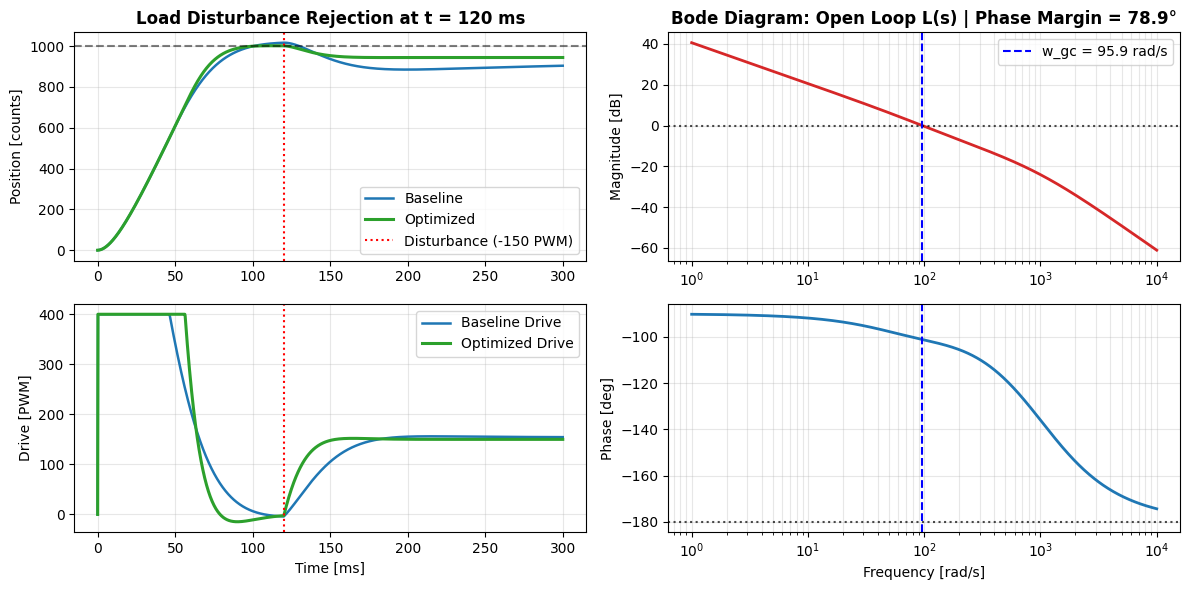

In [8]:
# 1. Disturbance Rejection Test
def simulate_position_disturbance(Kp, Ki, Kd, setpoint=1000.0, t_end=0.3, dt=0.0002, u_max=400.0):
    t_arr = np.arange(0, t_end, dt)
    n = len(t_arr)
    pos = np.zeros(n)
    vel = np.zeros(n)
    u = np.zeros(n)
    integral = 0.0
    
    for i in range(1, n):
        err = setpoint - pos[i-1]
        deriv = -vel[i-1]
        dist = -150.0 if t_arr[i] >= 0.12 else 0.0
        
        u_cand = Kp * err + Ki * integral + Kd * deriv
        u_sat = np.clip(u_cand, -u_max, u_max)
        
        if not ((u_cand > u_max and err > 0) or (u_cand < -u_max and err < 0)):
            integral += err * dt
            
        u[i] = u_sat
        dvel = -a_fit * vel[i-1] + b_fit * (u_sat + dist)
        vel[i] = vel[i-1] + dvel * dt
        pos[i] = pos[i-1] + vel[i] * dt
        
    return t_arr, pos, u

t_dist, pos_dist_base, u_dist_base = simulate_position_disturbance(Kp_p_base, Ki_p_base, Kd_p_base)
t_dist, pos_dist_opt, u_dist_opt = simulate_position_disturbance(Kp_p_opt, Ki_p_opt, Kd_p_opt)

# 2. Bode Diagram
Tf = 0.001
num_C = [Kd_p_opt + Kp_p_opt * Tf, Kp_p_opt + Ki_p_opt * Tf, Ki_p_opt]
den_C = [Tf, 1.0, 0.0]
num_G = [b_fit]
den_G = [1.0, a_fit, 0.0]

num_L = np.polymul(num_C, num_G)
den_L = np.polymul(den_C, den_G)

sys_L = signal.lti(num_L, den_L)
w = np.logspace(0, 4, 1000)
w, mag, phase = signal.bode(sys_L, w=w)

idx_gc = np.argmin(np.abs(mag))
w_gc = w[idx_gc]
pm = 180.0 + phase[idx_gc]

print(f"Frequency Margins:")
print(f"  Gain Crossover Frequency (w_gc) : {w_gc:.1f} rad/s ({w_gc/(2*np.pi):.1f} Hz)")
print(f"  Phase Margin (PM)               : {pm:.1f}° (Target: > 50° -> Highly stable)")

# Plot Disturbance & Bode
fig = plt.figure(figsize=(12, 6))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(t_dist * 1e3, pos_dist_base, label="Baseline", color="tab:blue", lw=1.8)
ax1.plot(t_dist * 1e3, pos_dist_opt, label="Optimized", color="tab:green", lw=2.2)
ax1.axvline(120.0, color="red", ls=":", label="Disturbance (-150 PWM)")
ax1.axhline(1000.0, color="black", ls="--", alpha=0.5)
ax1.set_ylabel("Position [counts]")
ax1.set_title("Load Disturbance Rejection at t = 120 ms", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(2, 2, 3)
ax2.plot(t_dist * 1e3, u_dist_base, color="tab:blue", lw=1.8, label="Baseline Drive")
ax2.plot(t_dist * 1e3, u_dist_opt, color="tab:green", lw=2.2, label="Optimized Drive")
ax2.axvline(120.0, color="red", ls=":")
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Drive [PWM]")
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = plt.subplot(2, 2, 2)
ax3.semilogx(w, mag, color="tab:red", lw=2)
ax3.axhline(0, color="black", ls=":", alpha=0.7)
ax3.axvline(w_gc, color="blue", ls="--", label=f"w_gc = {w_gc:.1f} rad/s")
ax3.set_ylabel("Magnitude [dB]")
ax3.set_title(f"Bode Diagram: Open Loop L(s) | Phase Margin = {pm:.1f}°", fontweight="bold")
ax3.grid(True, which="both", alpha=0.3)
ax3.legend()

ax4 = plt.subplot(2, 2, 4)
ax4.semilogx(w, phase, color="tab:blue", lw=2)
ax4.axhline(-180, color="black", ls=":", alpha=0.7)
ax4.axvline(w_gc, color="blue", ls="--")
ax4.set_xlabel("Frequency [rad/s]")
ax4.set_ylabel("Phase [deg]")
ax4.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 9: Translation to ESP32 Firmware (`main/motor_pid.c`)

### Discrete Scaling in Espressif `pid_ctrl`
In `main/motor_pid.c`:
- `ts_inner = 0.001` (1 ms tick for velocity loop)
- `ts_outer = 0.005` (5 ms tick for position loop)

In the cascaded configuration:
1. `pid_velocity` takes `velocity_target - velocity_measured` and outputs into PWM duty.
2. `pid_position` takes `position_target - position_measured` and outputs into `velocity_target` (bounded by `.max_output = setMotorVelocity(...)`).


In [9]:
print("=" * 75)
print(f"{'RECOMMENDED PID PARAMETERS FOR FIRMWARE (main/motor_pid.c)':^75}")
print("=" * 75)

print(f"\n1. INNER VELOCITY LOOP (pid_velocity in main/motor_pid.c, ts_inner = 0.001 s):")
print(f"   kp = {Kp_v_opt:.6f}f;")
print(f"   ki = {Ki_v_opt:.6f}f * ts_inner;  // discrete Ki = {Ki_v_opt*0.001:.6f}")
print(f"   kd = 0.0f;")

print(f"\n2. OUTER POSITION LOOP (pid_position in main/motor_pid.c, ts_outer = 0.005 s):")
print(f"   kp = {Kp_pos_cascade:.2f}f;")
print(f"   ki = 0.005f * ts_outer;  // small trim for friction/gravity")
print(f"   kd = 0.0f;  // damping is already provided by the inner velocity loop!")

print("\n" + "=" * 75)
print("C Code Snippet for update_pid_params() in main/motor_pid.c:")
print("-" * 75)
c_snippet = f"""
    // --- Inner Velocity Loop (Velocity -> PWM) ---
    pid_params[pid_velocity].kp = {Kp_v_opt:.6f}f;
    pid_params[pid_velocity].ki = {Ki_v_opt:.6f}f * ts_inner;
    pid_params[pid_velocity].kd = 0.0f;
    err |= pid_update_parameters(pid_ctrls[pid_velocity], &pid_params[pid_velocity]);

    // --- Outer Position Loop (Position -> Velocity Target) ---
    pid_params[pid_position].kp = {Kp_pos_cascade:.2f}f;
    pid_params[pid_position].ki = 0.005f * ts_outer;
    pid_params[pid_position].kd = 0.0f; // Inner velocity loop provides damping!
    err |= pid_update_parameters(pid_ctrls[pid_position], &pid_params[pid_position]);
"""
print(c_snippet)
print("=" * 75)


        RECOMMENDED PID PARAMETERS FOR FIRMWARE (main/motor_pid.c)         

1. INNER VELOCITY LOOP (pid_velocity in main/motor_pid.c, ts_inner = 0.001 s):
   kp = 0.045714f;
   ki = 4.755149f * ts_inner;  // discrete Ki = 0.004755
   kd = 0.0f;

2. OUTER POSITION LOOP (pid_position in main/motor_pid.c, ts_outer = 0.005 s):
   kp = 25.00f;
   ki = 0.005f * ts_outer;  // small trim for friction/gravity
   kd = 0.0f;  // damping is already provided by the inner velocity loop!

C Code Snippet for update_pid_params() in main/motor_pid.c:
---------------------------------------------------------------------------

    // --- Inner Velocity Loop (Velocity -> PWM) ---
    pid_params[pid_velocity].kp = 0.045714f;
    pid_params[pid_velocity].ki = 4.755149f * ts_inner;
    pid_params[pid_velocity].kd = 0.0f;
    err |= pid_update_parameters(pid_ctrls[pid_velocity], &pid_params[pid_velocity]);

    // --- Outer Position Loop (Position -> Velocity Target) ---
    pid_params[pid_position].kp = 25.